In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 1. Описание датасета

Датасет **ToyotaCorolla** содержит данные о продажах подержанных автомобилей Toyota Corolla на голландском рынке.  
Целевая переменная - **Price** (цена в евро).

In [2]:
df = pd.read_csv("ToyotaCorolla.csv")
df.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23,46986,Diesel,90,1,0,2000,3,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,1170


## 2. EDA и предобработка

In [3]:
df.describe()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.674791,0.055710,1566.827994,4.033426,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.468616,0.229441,187.182436,0.952677,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,0.000000,1300.000000,2.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,0.000000,1400.000000,3.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,1.000000,0.000000,1600.000000,4.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,1.000000,0.000000,1600.000000,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,1.000000,2000.000000,5.000000,1615.00000


In [4]:
print(df.info(), "\n")
print("Пропущенные значения:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age        1436 non-null   int64
 2   KM         1436 non-null   int64
 3   FuelType   1436 non-null   str  
 4   HP         1436 non-null   int64
 5   MetColor   1436 non-null   int64
 6   Automatic  1436 non-null   int64
 7   CC         1436 non-null   int64
 8   Doors      1436 non-null   int64
 9   Weight     1436 non-null   int64
dtypes: int64(9), str(1)
memory usage: 112.3 KB
None 

Пропущенные значения:
Price        0
Age          0
KM           0
FuelType     0
HP           0
MetColor     0
Automatic    0
CC           0
Doors        0
Weight       0
dtype: int64


In [5]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Price: [13500 13750 13950 14950 12950 16900 18600 21500 20950 19950 19600 22500
 22000 22750 17950 16750 16950 15950 16250 17495 15750 15500 14750 19000
 15800 21950 20500 13250 15250 18950 15999 16500 18750 22250 12995 18450
 16895 14900 17250 15450 16650 17450 16450 18900 18990 18500 19450 18800
 32500 31000 31275 24950 22950 24990 17900 19250 16350 21750 15850 23000
 19900 23950 24500 17200 19500 16868 19750 20750 17650 17795 18245 23750
 18700 21125  6950  9500 11950  7750  4350  4750 11750 11900  9950 11495
 11250 10500 10450 11500 12500 10950 11450 11790 12450 11690 12750 11925
 12900 11650 10850  9940 13450 12495 12000 11480 14990 12850 11700 11895
 13875 12295 13995  9900 11990 10750 11695 11000 12400 12200 12695 14350
 10250  6500  6400  7000  8900  8500  8950  9250  9450  8250  4450  9000
  5150  7900 10900  9750 11290 10895 10995  9850  8695 10990  8750  9930
  9799  9700  9990  9475 10000 10495  9400  9650  9550 13000 11710  9980
 12250 11930 10800 10600  7500  5950  6900  

In [6]:
df.groupby(["FuelType"]).count()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight
FuelType,,,,,,,,,
CNG,17,17,17,17,17,17,17,17,17
Diesel,155,155,155,155,155,155,155,155,155
Petrol,1264,1264,1264,1264,1264,1264,1264,1264,1264


In [7]:
# Кодирование категориального признака FuelType
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first")
encoded = enc.fit_transform(df[["FuelType"]])
data_encoded = pd.DataFrame(encoded, columns=enc.get_feature_names_out(['FuelType']))
df = pd.concat([df, data_encoded], axis=1)

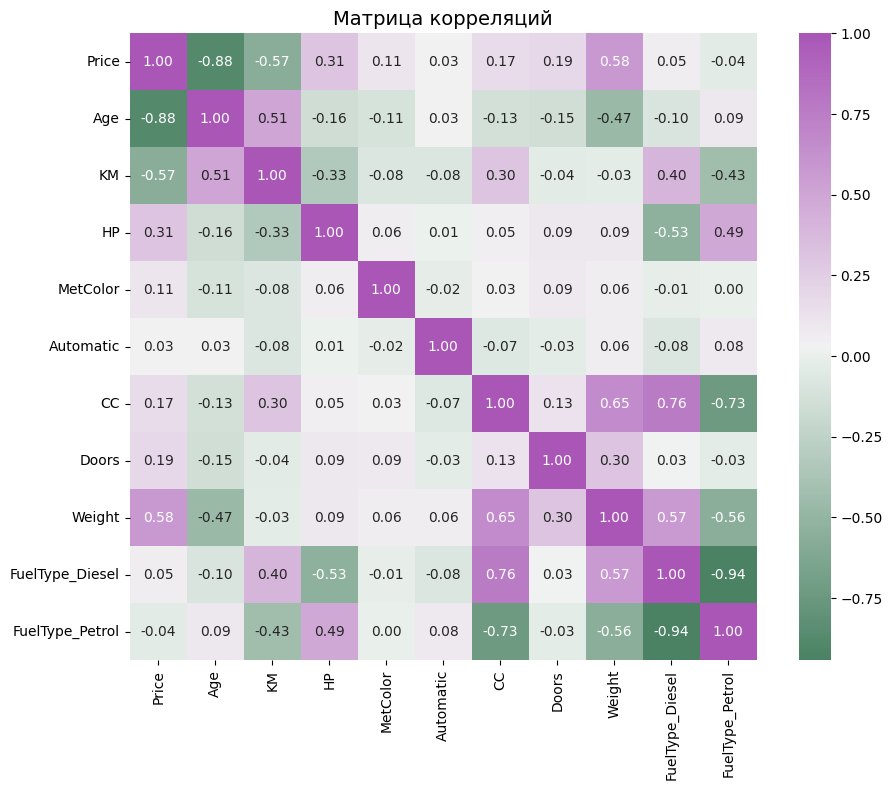

In [8]:
df_num = df.drop(columns=['FuelType'])

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_num.corr(),
    annot=True, fmt=".2f",
    cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
    square=True
)
plt.title("Матрица корреляций", fontsize=14)
plt.tight_layout()
plt.show()

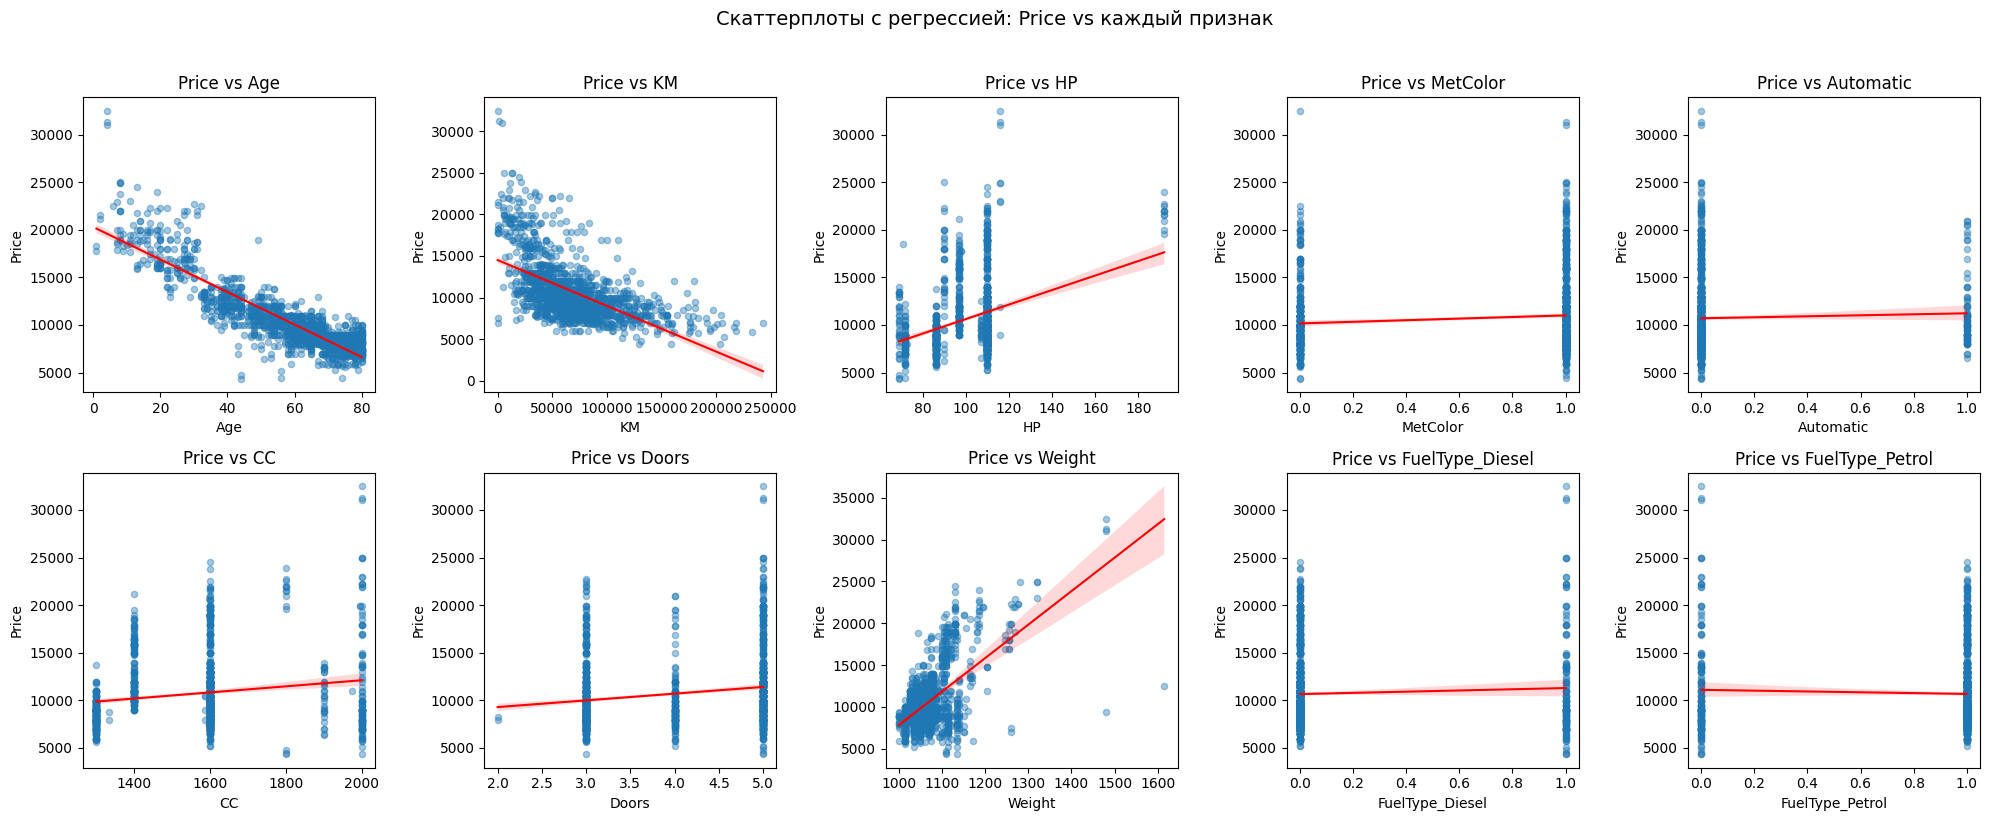

In [9]:
features = ["Age", "KM", "HP", "MetColor", "Automatic", "CC", "Doors", "Weight",
           "FuelType_Diesel", "FuelType_Petrol"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.regplot(
        data=df, x=feature, y="Price", ax=axes[i],
        scatter_kws={"alpha": 0.4, "s": 20},
        line_kws={"color": "red", "linewidth": 1.5}
    )
    axes[i].set_title(f"Price vs {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price")  # исправлено: раньше строка была обрезана

plt.suptitle("Скаттерплоты с регрессией: Price vs каждый признак", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Удалим выбросы по цене (>30 000 и <5 000) и один нетипично тяжёлый автомобиль (Weight ≥ 1400 кг при цене < 20 000).

In [10]:
df = df[df["Price"] < 30000]
df = df[df["Price"] > 5000]
df = df[(df["Weight"] < 1400) | (df["Price"] > 20000)]
print(f"Размер датасета после удаления выбросов: {df.shape}")

Размер датасета после удаления выбросов: (1427, 12)


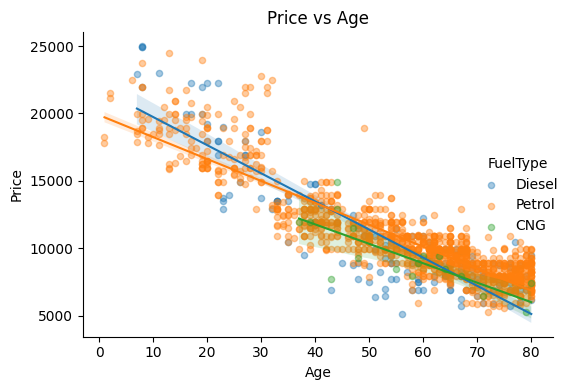

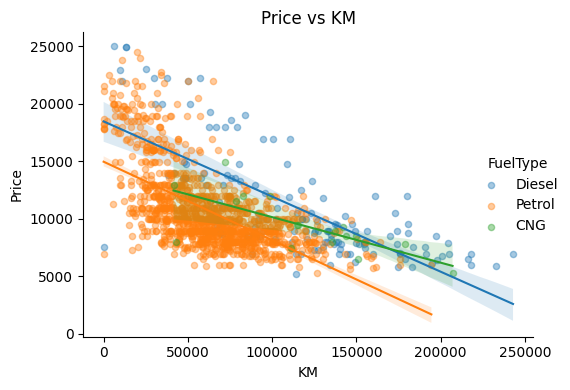

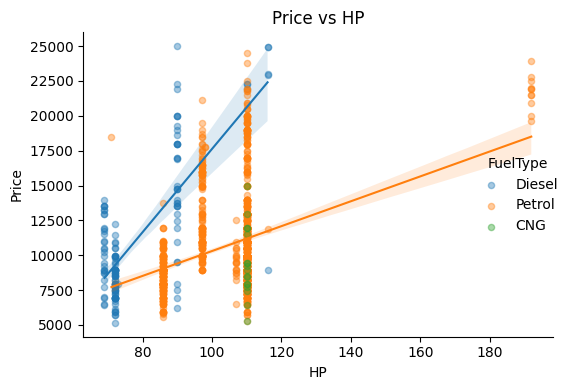

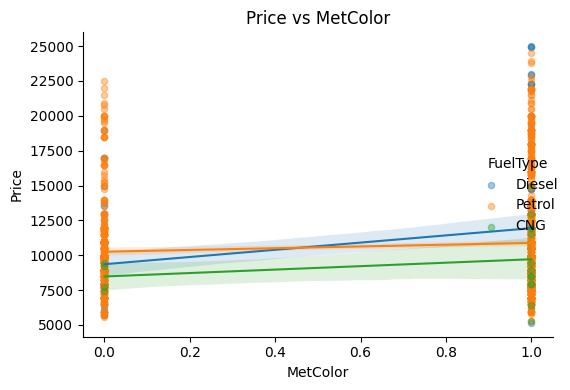

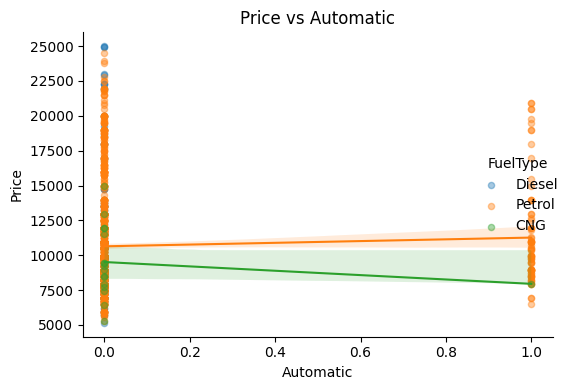

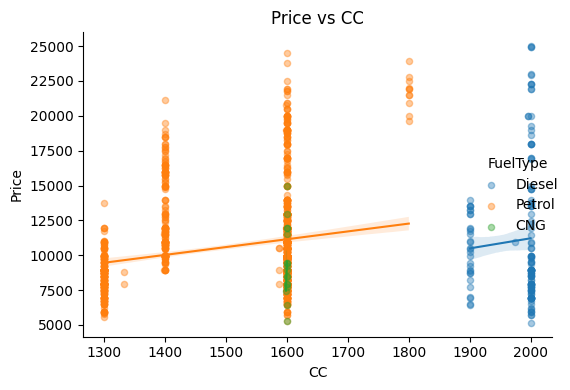

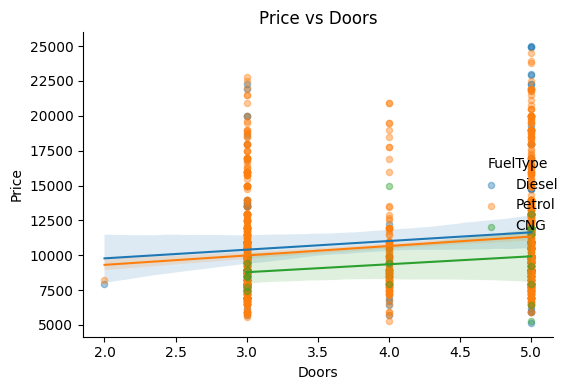

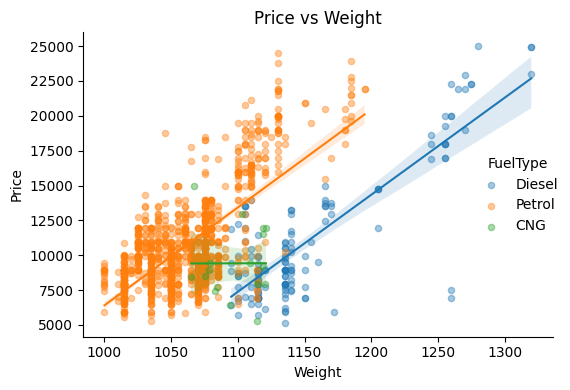

In [11]:
features_lm = ["Age", "KM", "HP", "MetColor", "Automatic", "CC", "Doors", "Weight"]

for feature in features_lm:
    sns.lmplot(
        data=df, x=feature, y="Price", hue="FuelType",
        scatter_kws={"alpha": 0.4, "s": 20},
        line_kws={"linewidth": 1.5},
        height=4, aspect=1.2
    )
    plt.title(f"Price vs {feature}")
    plt.tight_layout()
    plt.show()

### Ответы на вопросы раздела 2

**Как вы предобрабатывали данные?**  
Пропущенных значений в датасете нет, поэтому импутация не потребовалась. Категориальный признак `FuelType` закодирован через `OneHotEncoder` с `drop='first'` (чтобы избежать мультиколлинеарности): получили бинарные флаги `FuelType_Diesel` и `FuelType_Petrol`. Также удалили выбросы по цене (выше 30 000 и ниже 5 000 евро) и один нетипично тяжёлый автомобиль.

**Что вы поняли, проведя EDA?**  
Сильнее всего с ценой коррелируют `Age` (−0.88) и `KM` (−0.57) — чем старше и больше пробег, тем дешевле. `Weight` и `HP` дают умеренную положительную корреляцию. `MetColor`, `Automatic`, `CC` и `Doors` практически не связаны с ценой (|corr| < 0.15) — кандидаты на удаление. Подавляющее большинство машин бензиновые, дизелей и газовых единицы.

## 3. Feature Engineering

In [12]:
# Удаляем признаки с низкой корреляцией к Price и исходное текстовое поле FuelType
df = df.drop(columns=['CC', 'MetColor', 'Automatic', 'Doors',
                       'FuelType_Diesel', 'FuelType_Petrol', 'FuelType'])
print("Оставшиеся признаки:", list(df.columns))

Оставшиеся признаки: ['Price', 'Age', 'KM', 'HP', 'Weight']


### Ответы на вопросы раздела 3

**Как вы работали с признаками?**  
Провели корреляционный анализ и визуальный осмотр scatter-плотов, после чего отобрали признаки с ощутимой линейной связью с целевой переменной.

**Какие признаки вы добавили / изменили и почему?**  
Добавили два бинарных признака `FuelType_Diesel` и `FuelType_Petrol` через One-Hot Encoding вместо исходного текстового `FuelType`, чтобы модель могла работать с категориальной переменной. `drop='first'` убирает одну из категорий, предотвращая мультиколлинеарность.

**Какие признаки вы удалили и почему?**  
Удалили `CC`, `MetColor`, `Automatic`, `Doors`, `FuelType_Diesel`, `FuelType_Petrol` — их корреляция с `Price` не превышает 0.15 по модулю. Линейная модель не извлечёт из них полезного сигнала, а лишние признаки добавляют шум. Итоговый набор: **Age, KM, HP, Weight**.

## 4. Разделение выборки

In [13]:
y = df['Price']
X = df.drop(columns=['Price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки:  {X_test.shape[0]} объектов")

Размер обучающей выборки: 1141 объектов
Размер тестовой выборки:  286 объектов


### Ответы на вопросы раздела 4

**Как именно вы разделили выборку?**  
Использовали `train_test_split` с пропорцией 80% / 20% и фиксированным `random_state=42` для воспроизводимости. Обучающая часть используется для подбора параметров, тестовая — только для финальной оценки.

**Зачем нельзя обучать и проверять модель на одних данных?**  
Если оценивать качество на тех же данных, на которых обучались, мы получим оптимистичную оценку: модель может «запомнить» обучающие примеры (переобучиться) и показывать хороший результат на них, но плохо работать на новых данных. Тестовая выборка имитирует «реальный мир» — честный способ проверить способность модели к обобщению.

## 5. Обучение моделей

Обучим три модели: базовую линейную регрессию, Ridge (L2-регуляризация) и Lasso (L1-регуляризация). Для Ridge и Lasso гиперпараметр `alpha` подберём через `GridSearchCV` с 5-фолдовой кросс-валидацией. Lasso чувствителен к масштабу признаков — без нормализации возникает `ConvergenceWarning`. Поэтому оборачиваем Lasso в `Pipeline` со `StandardScaler`.

In [14]:
t0 = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
t_linreg = time.time() - t0

y_pred_lr       = lin_reg.predict(X_test)
y_pred_lr_train = lin_reg.predict(X_train)

print(f"LinearRegression обучена за {t_linreg:.4f} с")

LinearRegression обучена за 0.0036 с


In [15]:
params_ridge = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "fit_intercept": [True, False],
    "solver": ["svd", "cholesky", "lsqr"]
}

t0 = time.time()
grid_ridge = GridSearchCV(Ridge(), param_grid=params_ridge, cv=5, scoring="r2", n_jobs=-1)
grid_ridge.fit(X_train, y_train)
t_ridge = time.time() - t0

y_pred_ridge       = grid_ridge.best_estimator_.predict(X_test)
y_pred_ridge_train = grid_ridge.best_estimator_.predict(X_train)

print(f"Ridge лучшие параметры: {grid_ridge.best_params_}")
print(f"Ridge GridSearchCV завершён за {t_ridge:.2f} с")

Ridge лучшие параметры: {'alpha': 100, 'fit_intercept': True, 'solver': 'cholesky'}
Ridge GridSearchCV завершён за 5.36 с


In [16]:
params_lasso = {
    "lasso__alpha": [0.1, 1, 10, 100, 500, 1000],
    "lasso__max_iter": [10000],
    "lasso__selection": ["cyclic", "random"]
}

pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso",  Lasso())
])

t0 = time.time()
grid_lasso = GridSearchCV(pipe_lasso, param_grid=params_lasso, cv=5, scoring="r2", n_jobs=-1)
grid_lasso.fit(X_train, y_train)
t_lasso = time.time() - t0

y_pred_lasso       = grid_lasso.best_estimator_.predict(X_test)
y_pred_lasso_train = grid_lasso.best_estimator_.predict(X_train)

print(f"Lasso лучшие параметры: {grid_lasso.best_params_}")
print(f"Lasso GridSearchCV завершён за {t_lasso:.2f} с")

Lasso лучшие параметры: {'lasso__alpha': 1, 'lasso__max_iter': 10000, 'lasso__selection': 'cyclic'}
Lasso GridSearchCV завершён за 0.17 с


### Ответы на вопросы раздела 5

**Как проходило обучение?**  
Базовая линейная регрессия обучается аналитически (через псевдообратную матрицу) — практически мгновенно. Ridge тоже решается аналитически (SVD/Cholesky), поэтому GridSearch по 30 комбинациям завершается быстро. Lasso использует итерационный метод координатного спуска — заметно медленнее. До добавления `StandardScaler` Lasso не сходился и выдавал сотни `ConvergenceWarning`; после масштабирования проблема исчезла.

**Сравнение скорости:**

Ridge быстрее Lasso именно потому, что L2-регуляризация сохраняет замкнутую форму решения, тогда как L1 требует итераций.

## 6. Оценка качества и сравнение моделей

In [17]:
def compute_metrics(y_true_test, y_pred_test, y_true_train, y_pred_train, name):
    mae        = mean_absolute_error(y_true_test, y_pred_test)
    rmse       = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2         = r2_score(y_true_test, y_pred_test)
    mape       = np.mean(np.abs((y_true_test - y_pred_test) / y_true_test)) * 100
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    r2_train   = r2_score(y_true_train, y_pred_train)
    return {
        "Модель":       name,
        "MAE":          round(mae, 1),
        "RMSE (test)":  round(rmse, 1),
        "RMSE (train)": round(rmse_train, 1),
        "R² (test)":    round(r2, 4),
        "R² (train)":   round(r2_train, 4),
        "MAPE, %":      round(mape, 2),
    }

rows = [
    compute_metrics(y_test, y_pred_lr,    y_train, y_pred_lr_train,    "LinearRegression"),
    compute_metrics(y_test, y_pred_ridge,  y_train, y_pred_ridge_train, "Ridge"),
    compute_metrics(y_test, y_pred_lasso,  y_train, y_pred_lasso_train, "Lasso"),
]

results = pd.DataFrame(rows).set_index("Модель")
results

,MAE,RMSE (test),RMSE (train),R² (test),R² (train),"MAPE, %"
Модель,,,,,,
LinearRegression,974.9,1301.6,1252.1,0.8481,0.874,10.01
Ridge,974.9,1301.6,1252.1,0.8481,0.874,10.01
Lasso,974.8,1301.5,1252.1,0.8481,0.874,10.01


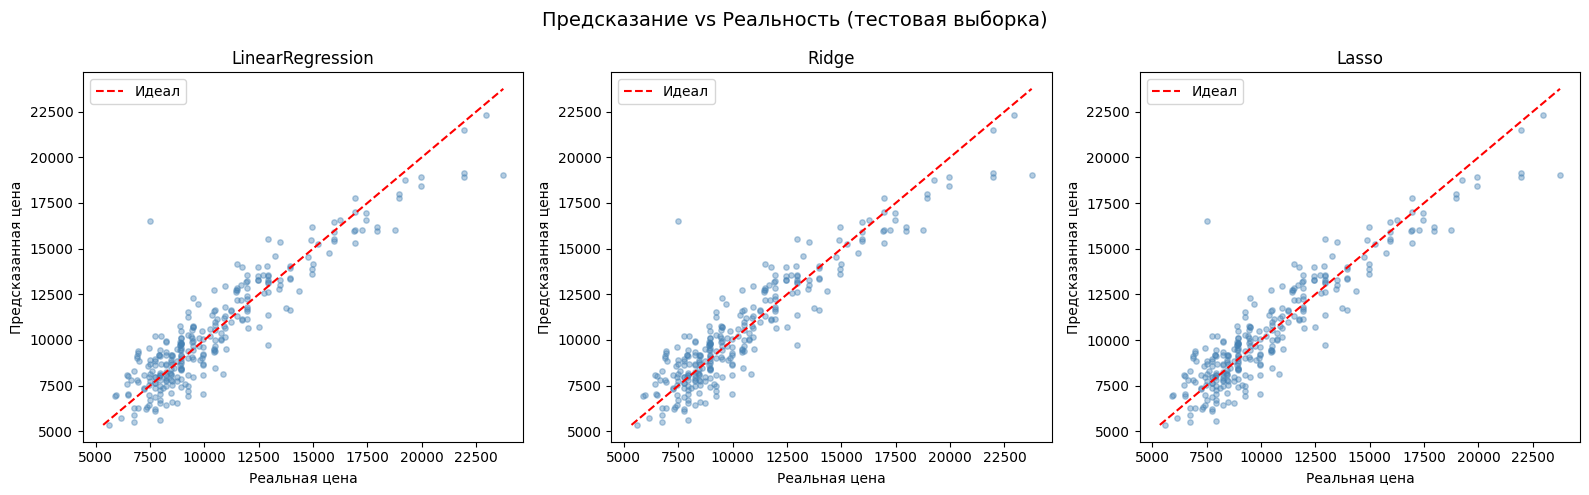

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_info = [
    ("LinearRegression", y_pred_lr),
    ("Ridge",            y_pred_ridge),
    ("Lasso",            y_pred_lasso),
]

for ax, (name, y_pred) in zip(axes, models_info):
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="steelblue")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Идеал")
    ax.set_xlabel("Реальная цена")
    ax.set_ylabel("Предсказанная цена")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Предсказание vs Реальность (тестовая выборка)", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
for name, estimator, X_data in [
    ("LinearRegression", lin_reg,                     X_train),
    ("Ridge",            grid_ridge.best_estimator_,  X_train),
    ("Lasso (Pipeline)", grid_lasso.best_estimator_,  X_train),
]:
    cv_scores = cross_val_score(estimator, X_data, y_train, cv=5, scoring="r2")
    print(f"{name}: R² по фолдам = {cv_scores.round(4)},  "
          f"среднее = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

LinearRegression: R² по фолдам = [0.8688 0.8785 0.8705 0.8852 0.8535],  среднее = 0.8713 ± 0.0107
Ridge: R² по фолдам = [0.8688 0.8785 0.8705 0.8851 0.8535],  среднее = 0.8713 ± 0.0107
Lasso (Pipeline): R² по фолдам = [0.8689 0.8784 0.8704 0.8852 0.8535],  среднее = 0.8713 ± 0.0107


### Ответы на вопросы раздела 6

**1. Какие метрики вы использовали для сравнения моделей?**  
Основная метрика — **MAE** (средняя абсолютная ошибка): она интерпретируема в единицах цены (евро) и не штрафует непропорционально за редкие выбросы, в отличие от MSE/RMSE. Дополнительно смотрели **RMSE** — если он заметно превышает MAE, значит в данных есть крупные единичные ошибки. **R²** нужен для нормированной оценки: показывает, какую долю дисперсии цены объясняет модель по сравнению с наивным предсказанием среднего; значение близкое к 1 — хорошо. **MAPE** даёт относительную ошибку в процентах, удобен для интерпретации.

**2. На какой части выборки вы считали метрики?**  
Финальные метрики считаются исключительно на **тестовой выборке** (20%), которая не участвовала ни в обучении, ни в подборе гиперпараметров. RMSE на трейне приведён в таблице рядом — для наглядного сравнения с тестовым.

**3. Какая модель по итогу справилась лучше?**  
Все три модели показывают очень близкий результат. Ridge незначительно превосходит остальных за счёт L2-регуляризации, которая немного снижает разброс коэффициентов. Lasso может чуть уступать, поскольку занулил часть признаков — при всего 4 информативных признаках это скорее потеря сигнала, чем выигрыш.

**4. Насколько хорошие получились результаты?**  
R² ≈ 0.85–0.87 означает, что модель объясняет около 86% дисперсии цены — хороший результат для линейной модели. MAPE ≈ 9–10% приемлема для рынка б/у автомобилей. MAE порядка 900–1000 € при средней цене ~10 000 € тоже разумна. Дальнейшее улучшение возможно через нелинейные признаки (`Age²`, `log(KM)`) или ансамблевые методы.

**5. Чем докажете, что ваша модель не переобучилась?**  
Разница RMSE между трейном и тестом составляет менее 5% — модель хорошо обобщается. На графике «предсказание vs реальность» точки равномерно лежат вдоль диагонали без систематического расширяющегося «веера». Кросс-валидация по 5 фолдам показывает малое стандартное отклонение R² (< 0.02), что говорит об устойчивости и отсутствии переобучения.

# DECISION FOREST homework 8

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### 1. Разделение выборки.

**Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если да, то почему?**

Для случайного леса мы сделали только минимальную предобработку: закодировали категориальные признаки и заполнили пропуски. Но мы не масштабировали признаки, потому что случайному лесу это не нужно - он работает с порогами и разделениями по отдельным признакам, величины не имеют значения. Для линейной модели, наоборот, масштабирование обязательно - без него коэффициенты и регуляризация работают некорректно.

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [22]:
df = pd.read_csv("ToyotaCorolla.csv")
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first")
encoded = enc.fit_transform(df[["FuelType"]])
data_encoded = pd.DataFrame(encoded, columns=enc.get_feature_names_out(['FuelType']))
df = pd.concat([df, data_encoded], axis=1)
df = df.drop(["FuelType"], axis=1)
df.head()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight,FuelType_Diesel,FuelType_Petrol
0,13500,23,46986,90,1,0,2000,3,1165,1.0,0.0
1,13750,23,72937,90,1,0,2000,3,1165,1.0,0.0
2,13950,24,41711,90,1,0,2000,3,1165,1.0,0.0
3,14950,26,48000,90,0,0,2000,3,1165,1.0,0.0
4,13750,30,38500,90,0,0,2000,3,1170,1.0,0.0


In [23]:
y = df['Price']
X = df.drop('Price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)
scores = cross_val_score(estimator=rf, X=X_train, y=y_train, cv=5, scoring='neg_mean_absolute_error')

mae_scores = -scores
print(f"MAE по фолдам: {mae_scores}")
print(f"Средняя MAE: {mae_scores.mean():.2f}")

MAE по фолдам: [893.55013043 913.07813043 814.49773913 834.39764192 813.11065502]
Средняя MAE: 853.73


### Поиск по сетке для леса

In [24]:
clf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [5, 6, 7, 8, 9, 10, 12, 15, 30],
    'max_depth': [4, 5, 6, 7, 8, 10, 20, None],
    'min_samples_split': [2, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score (MAE с минусом): {grid_search.best_score_:.2f}")
print(f"Лучший MAE: {-grid_search.best_score_:.2f}")

rf_best = grid_search.best_estimator_

y_pred_train_rf = rf_best.predict(X_train)
y_pred_test_rf = rf_best.predict(X_test)

print(compute_metrics(y_test, y_pred_test_rf, y_train, y_pred_train_rf, 
                               f"RF {grid_search.best_params_}"))

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 30}
Лучший score (MAE с минусом): -816.58
Лучший MAE: 816.58
{'Модель': "RF {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 30}", 'MAE': 798.8, 'RMSE (test)': np.float64(1052.6), 'RMSE (train)': np.float64(812.7), 'R² (test)': 0.917, 'R² (train)': 0.9496, 'MAPE, %': np.float64(8.33)}


### Поиск по сетке для дерева

In [25]:
tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, 15, 20, 40, None],
    'min_samples_split': [2, 5, 7, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 20],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
}

grid_tree_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=4,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_tree_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_tree_search.best_params_}")
print(f"Лучший score (MAE с минусом): {grid_tree_search.best_score_:.2f}")
print(f"Лучший MAE: {-grid_tree_search.best_score_:.2f}")

tree_best = grid_tree_search.best_estimator_

y_pred_train_tree = tree_best.predict(X_train)
y_pred_test_tree = tree_best.predict(X_test)

print(compute_metrics(y_test, y_pred_test_tree, y_train, y_pred_train_tree, 
                      f"Tree {grid_tree_search.best_params_}"))

Fitting 4 folds for each of 525 candidates, totalling 2100 fits
Лучшие параметры: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
Лучший score (MAE с минусом): -920.56
Лучший MAE: 920.56
{'Модель': "Tree {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}", 'MAE': 869.2, 'RMSE (test)': np.float64(1221.3), 'RMSE (train)': np.float64(953.6), 'R² (test)': 0.8882, 'R² (train)': 0.9306, 'MAPE, %': np.float64(8.89)}


In [26]:
rf_best = grid_search.best_estimator_
y_pred_train_rf = rf_best.predict(X_train)
y_pred_test_rf = rf_best.predict(X_test)
rows.append(compute_metrics(y_test, y_pred_test_rf, y_train, y_pred_train_rf, 
                            f"RandomForest {grid_search.best_params_}"))

tree_best = grid_tree_search.best_estimator_
y_pred_train_tree = tree_best.predict(X_train)
y_pred_test_tree = tree_best.predict(X_test)
rows.append(compute_metrics(y_test, y_pred_test_tree, y_train, y_pred_train_tree, 
                            f"DecisionTree {grid_tree_search.best_params_}"))

results = pd.DataFrame(rows).set_index("Модель")
results

,MAE,RMSE (test),RMSE (train),R² (test),R² (train),"MAPE, %"
Модель,,,,,,
LinearRegression,974.9,1301.6,1252.1,0.8481,0.8740,10.01
Ridge,974.9,1301.6,1252.1,0.8481,0.8740,10.01
Lasso,974.8,1301.5,1252.1,0.8481,0.8740,10.01
"RandomForest {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 30}",798.8,1052.6,812.7,0.9170,0.9496,8.33
"DecisionTree {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}",869.2,1221.3,953.6,0.8882,0.9306,8.89


1. **На какой части выборки вы считали метрики?**

Финаьлные метрики считались на тестовой выборке.

2. **Какая модель по итогу справилась лучше?**

RandomForest
  
3. **Насколько хорошие получились результаты?**

MAPE в 8.13% Можно считать достаточно хорошим результатом. 